# ⚡ AdaBoost (Adaptive Boosting) – Step-by-Step Implementation  

## Objective:
To understand AdaBoost by manually implementing weight updates, weak learners, and final prediction using weighted voting.

## 🎯 What is AdaBoost?

AdaBoost is a boosting technique that improves model performance by:

* Training models sequentially
* Increasing focus on misclassified data points
* Assigning weights to both data points and models
* Combining weak learners into a strong classifier

## 📦 Importing Libraries  

Importing required libraries for data manipulation, visualization, and model building.

In [19]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [20]:
df = pd.DataFrame()

## 📂 Dataset Preparation  

Creating a small dataset with two features to visualize decision boundaries and boosting behavior.

In [21]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [22]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


## 📊 Data Visualization  

Visualizing data points to understand class distribution.

<Axes: xlabel='X1', ylabel='X2'>

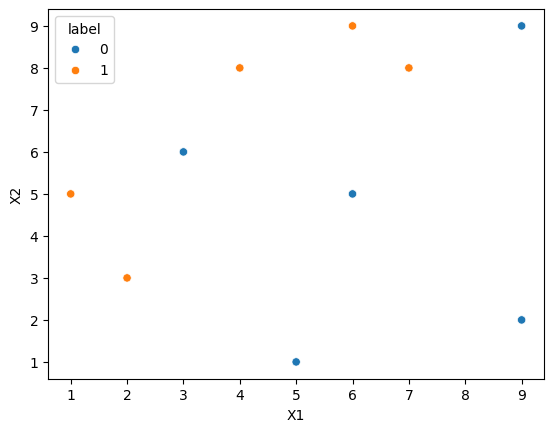

In [23]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

### 🔍 Observation:
Data points are not perfectly separable, making it suitable for boosting.

In [24]:
print(df.shape[0])

10


## ⚖️ Initial Weights  

Assigning equal weights to all data points.

In [25]:
df['weights'] = 1/df.shape[0]

In [26]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


## 🌱 First Weak Learner  

Training a Decision Tree stump (max_depth=1).

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [29]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [30]:
# Step 2 - Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

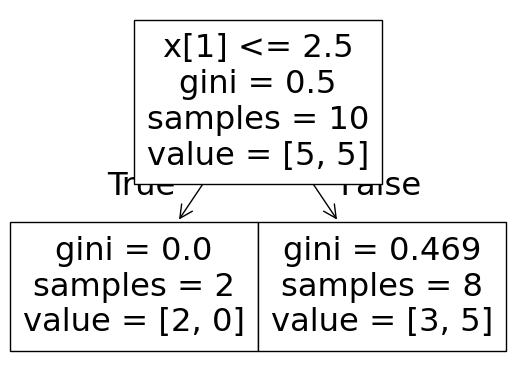

In [31]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

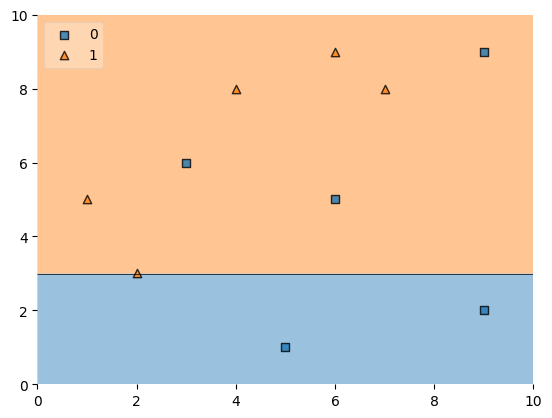

In [32]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [33]:
df['y_pred'] = dt1.predict(X)

In [34]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [36]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

## 📐 Model Weight Calculation  

Calculating alpha based on model error.

In [37]:
# Step 3 - calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

## 🔄 Updating Data Weights  

Increasing weights of misclassified points and decreasing weights of correctly classified points.

In [38]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [39]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [41]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


### 🔍 Observation:
Misclassified points get higher importance in the next iteration.

In [42]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [61]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [62]:
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [45]:
df['nomalized_weights'].sum()

np.float64(1.0)

In [46]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])

In [47]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [48]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [50]:
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


## 🎯 Resampling  

Creating a new dataset based on updated weights.

In [72]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [83]:
index_values = create_new_dataset(df)

index_values

[2, 3, 3, 2, 2, 6, 4, 1, 2, 9]

In [84]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [85]:
second_df

,X1,X2,label,weights
2,3,6,0,0.1
3,4,8,1,0.1
3,4,8,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1
4,5,1,0,0.1
1,2,3,1,0.1
2,3,6,0,0.1
9,9,2,0,0.1


## 🌱 Second Weak Learner  

Training another model focusing on difficult data points.

In [86]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [87]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [88]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.625, 0.5, '  False')]

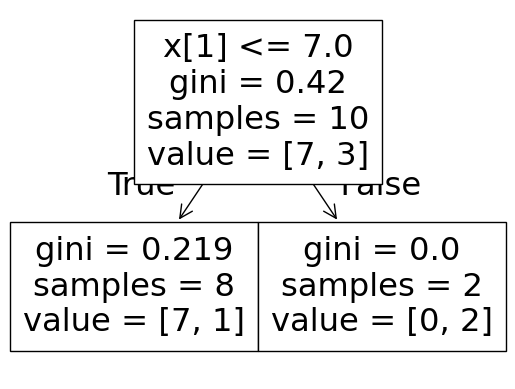

In [89]:
plot_tree(dt2)

<Axes: >

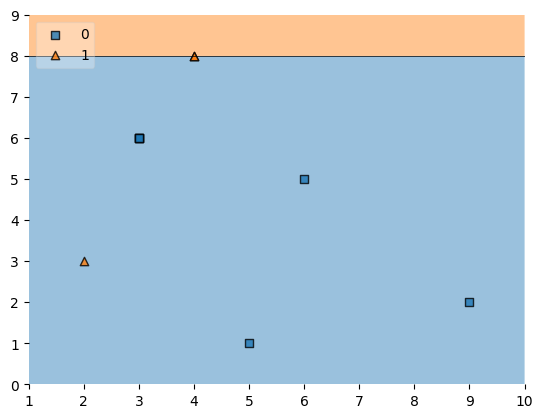

In [90]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [91]:
second_df['y_pred'] = dt2.predict(X)

In [92]:
second_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
3,4,8,1,0.1,1
3,4,8,1,0.1,1
2,3,6,0,0.1,0
2,3,6,0,0.1,0
6,6,5,0,0.1,0
4,5,1,0,0.1,0
1,2,3,1,0.1,0
2,3,6,0,0.1,0
9,9,2,0,0.1,0


In [93]:
alpha2 = calculate_model_weight(0.1)

In [94]:
alpha2

np.float64(1.0986122886681098)

In [95]:
# Step 4 - Update weights
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [96]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [97]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
2,3,6,0,0.1,0,0.033622
3,4,8,1,0.1,1,0.033622
3,4,8,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.033622
2,3,6,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
1,2,3,1,0.1,0,0.297427
2,3,6,0,0.1,0,0.033622
9,9,2,0,0.1,0,0.033622


In [98]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [99]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
2,3,6,0,0.1,0,0.033622,0.056034
3,4,8,1,0.1,1,0.033622,0.056034
3,4,8,1,0.1,1,0.033622,0.056034
2,3,6,0,0.1,0,0.033622,0.056034
2,3,6,0,0.1,0,0.033622,0.056034
6,6,5,0,0.1,0,0.033622,0.056034
4,5,1,0,0.1,0,0.033622,0.056034
1,2,3,1,0.1,0,0.297427,0.495694
2,3,6,0,0.1,0,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034


In [100]:
second_df['nomalized_weights'].sum()

np.float64(0.9999999999999999)

In [101]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [102]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [103]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
2,3,6,0,0.1,0,0.056034,0.000000,0.056034
3,4,8,1,0.1,1,0.056034,0.056034,0.112068
3,4,8,1,0.1,1,0.056034,0.112068,0.168102
2,3,6,0,0.1,0,0.056034,0.168102,0.224136
2,3,6,0,0.1,0,0.056034,0.224136,0.280170
6,6,5,0,0.1,0,0.056034,0.280170,0.336204
4,5,1,0,0.1,0,0.056034,0.336204,0.392238
1,2,3,1,0.1,0,0.495694,0.392238,0.887932
2,3,6,0,0.1,0,0.056034,0.887932,0.943966
9,9,2,0,0.1,0,0.056034,0.943966,1.000000


In [109]:
index_values = create_new_dataset(second_df)

## 🌱 Third Weak Learner  

Repeating the boosting process.

In [110]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [111]:
third_df

,X1,X2,label,weights
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
9,9,2,0,0.1
3,4,8,1,0.1
3,4,8,1,0.1


In [112]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

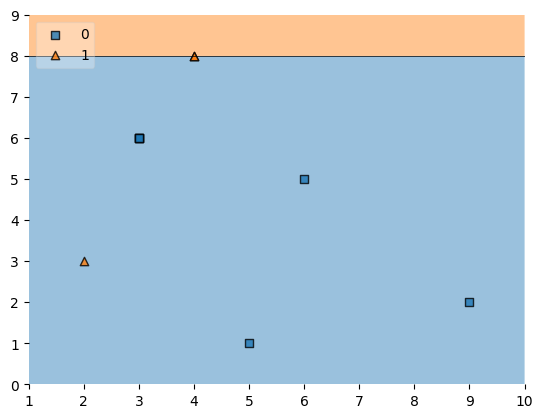

In [113]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [114]:
third_df['y_pred'] = dt3.predict(X)

In [115]:
third_df

,X1,X2,label,weights,y_pred
3,4,8,1,0.1,0
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,0
3,4,8,1,0.1,0
2,3,6,0,0.1,0
3,4,8,1,0.1,0
9,9,2,0,0.1,0
3,4,8,1,0.1,0
3,4,8,1,0.1,0


In [116]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [117]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


## 🧮 Final Prediction  

Combining predictions using weighted voting.

In [118]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [119]:
dt2.predict(query)

array([0])

In [120]:
dt3.predict(query)

array([0])

In [121]:
alpha1*1 + alpha2*(-1) + alpha3*(-1)

np.float64(-0.2513144282809062)

In [122]:
np.sign(1.09)

np.float64(1.0)

In [ ]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([1])

In [ ]:
dt2.predict(query)

array([0])

In [ ]:
dt3.predict(query)

array([0])

In [ ]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

-0.2513144282809062

In [ ]:
np.sign(-0.25)

-1.0

### 🔍 Final Insight:
AdaBoost improves performance by focusing on difficult data points and combining multiple weak learners into a strong model.